# Results of recording and subject LOO for binary classification for individual emotions

In [20]:
import os 
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
root_dir = "../../../"
results_root_dir = os.path.join(root_dir, "results/binary/")
results_dirs = {
    "anger": "RETAIN_2026-02-12_19-05-24",
    "disgust": "RETAIN_2026-02-12_19-19-45",
    "sadness": "RETAIN_2026-02-12_19-34-11",
    "tenderness": "RETAIN_2026-02-12_19-45-27"
}
subdirs = ["recording_loo", "subject_loo"]
summary_file = "summary.csv"

## Load results

In [22]:
all_results = []
for emotion, dir_name in results_dirs.items():
    for subdir in subdirs:
        path = os.path.join(results_root_dir, dir_name, subdir, summary_file)
        if os.path.exists(path):
            df = pd.read_csv(path)
            df["loo_type"] = subdir
            df["emotion"] = emotion
            # drop rows with "aggregated" under "metric_type"
            df = df[df["metric_type"] != "aggregated"]
            all_results.append(df)
        else:
            print(f"Warning: {path} not found, skipping.")

## Plot 

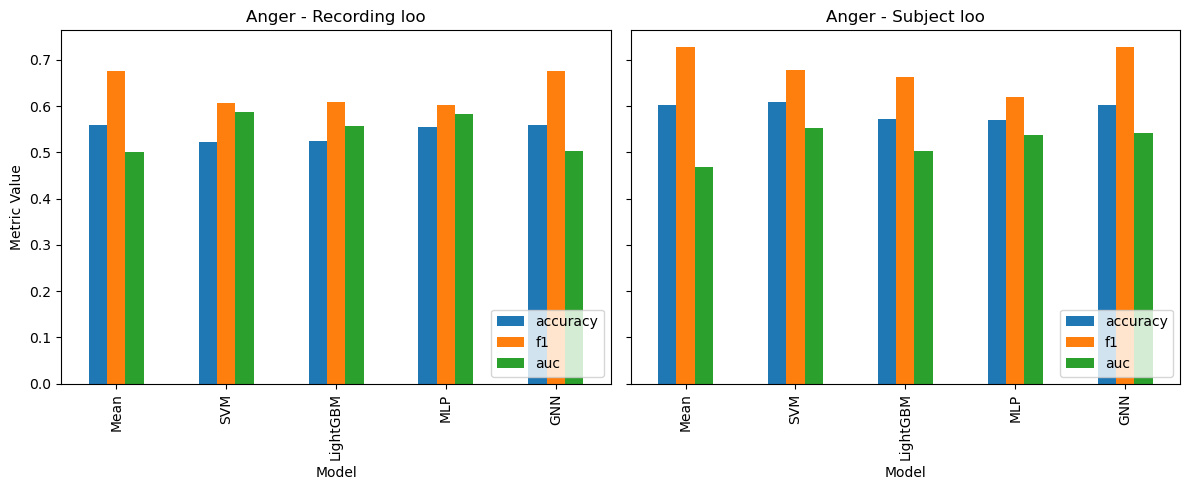

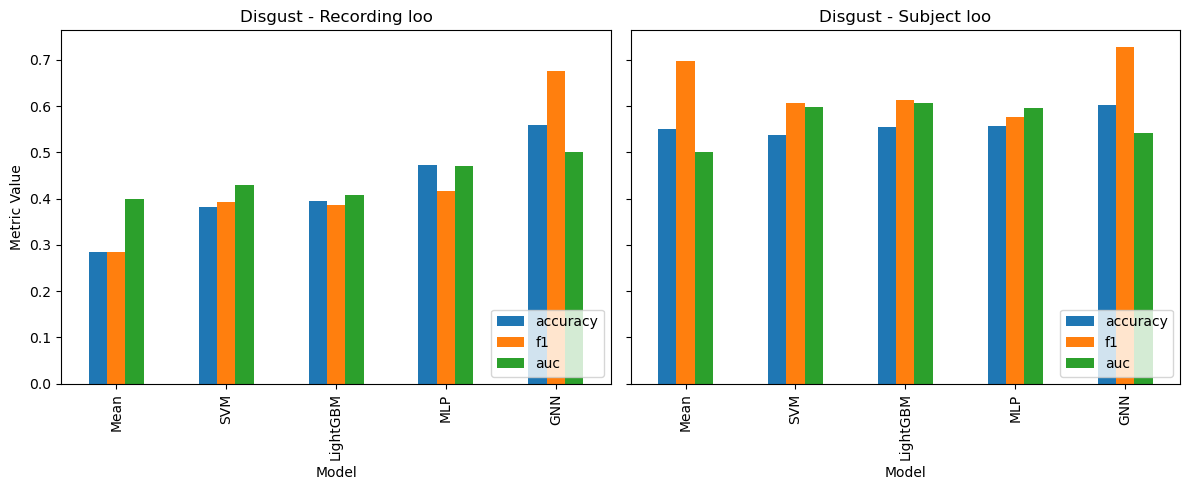

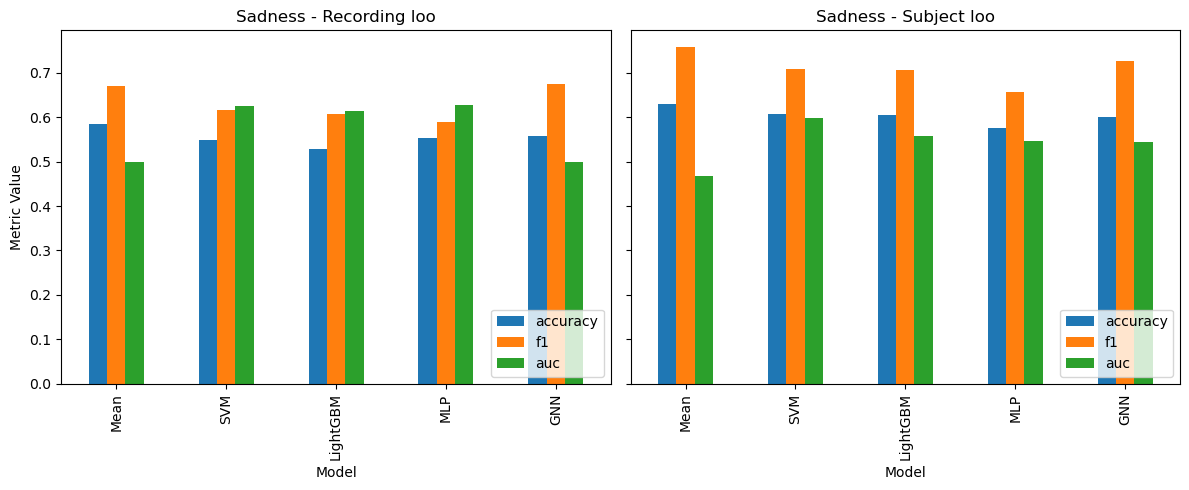

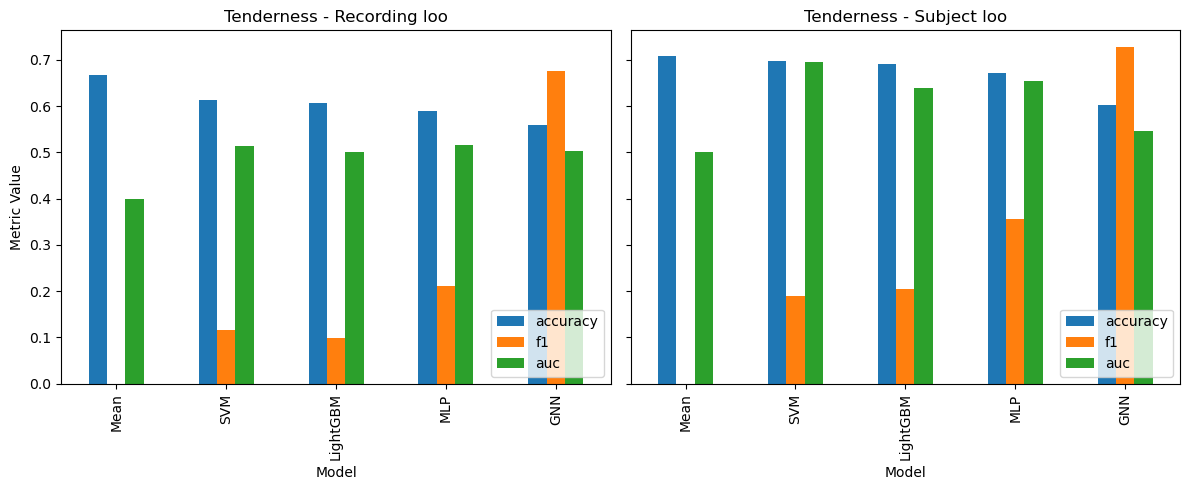

In [23]:
# for each emotion plot two barplots (one for recording_loo and one for subject_loo) showing the metrics (accuracy, f1, auc) for each model
for emotion in results_dirs.keys():
    emotion_results = pd.concat([df[df["emotion"] == emotion] for df in all_results])
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    for i, subdir in enumerate(subdirs):
        subdir_results = emotion_results[emotion_results["loo_type"] == subdir]
        subdir_results.plot(x="model", y=["accuracy", "f1", "auc"], kind="bar", ax=axes[i])
        axes[i].set_title(f"{emotion.capitalize()} - {subdir.replace('_', ' ').capitalize()}")
        axes[i].set_xlabel("Model")
        axes[i].set_ylabel("Metric Value")
        axes[i].legend(loc="lower right")
    plt.tight_layout()
    plt.show()